In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [50]:
ratings = pd.read_csv(r'C:\Users\Admin\Desktop\4_sem\ML\EX_NO_10\ml-latest-small\ratings.csv')
movies = pd.read_csv(r'C:\Users\Admin\Desktop\4_sem\ML\EX_NO_10\ml-latest-small\movies.csv')

print(ratings.head())
print(movies.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [51]:
# Merge datasets
data = pd.merge(ratings, movies, on='movieId')

# Keep only needed columns
data = data[['userId', 'movieId', 'rating']]

print(data.shape)

(100836, 3)


In [52]:
user_item_matrix = data.pivot_table(index='userId', columns='movieId', values='rating')

print(user_item_matrix.head())

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     NaN     4.0     NaN     NaN     4.0     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  9       10      ...  193565  193567  193571  193573  193579  193581  \
userId                   ...                                                   
1           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN  ...     NaN     NaN     NaN     NaN     NaN     N

In [53]:
# Fill missing values with 0
matrix_filled = user_item_matrix.fillna(0)

In [54]:
train, test = train_test_split(data, test_size=0.2, random_state=42)

In [55]:
k = 50  # latent factors

svd = TruncatedSVD(n_components=k, random_state=42)
U = svd.fit_transform(matrix_filled)
Sigma = svd.singular_values_
VT = svd.components_

In [56]:
reconstructed_matrix = np.dot(U, VT)

reconstructed_df = pd.DataFrame(reconstructed_matrix, 
                                index=matrix_filled.index, 
                                columns=matrix_filled.columns)

In [57]:
# Convert matrices to array
actual = matrix_filled.values
predicted = reconstructed_matrix

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("SVD RMSE:", rmse)
print("SVD MAE:", mae)

SVD RMSE: 0.3065756626340511
SVD MAE: 0.09294041209373106


In [58]:
def recommend_movies(user_id, n=5):
    user_ratings = reconstructed_df.loc[user_id]
    sorted_movies = user_ratings.sort_values(ascending=False)
    return sorted_movies.head(n)

print(recommend_movies(user_id=1, n=10))

movieId
260     6.923456
1196    6.644699
1198    6.611688
1210    6.124899
1291    5.987938
608     5.514544
47      5.203002
296     5.122181
2115    5.055617
2858    5.043141
Name: 1, dtype: float64


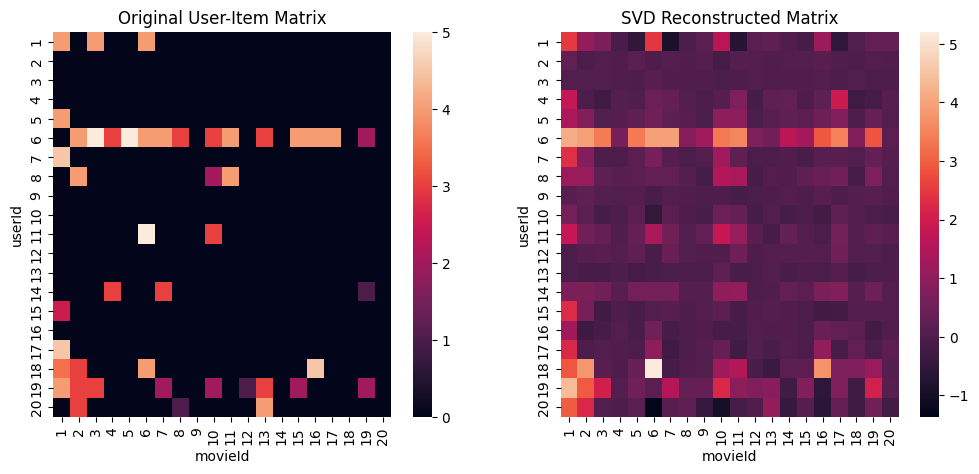

In [59]:
plt.figure(figsize=(12,5))

# Original Matrix
plt.subplot(1,2,1)
sns.heatmap(matrix_filled.iloc[:20, :20])
plt.title("Original User-Item Matrix")

# Reconstructed Matrix (SVD)
plt.subplot(1,2,2)
sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.title("SVD Reconstructed Matrix")

plt.show()

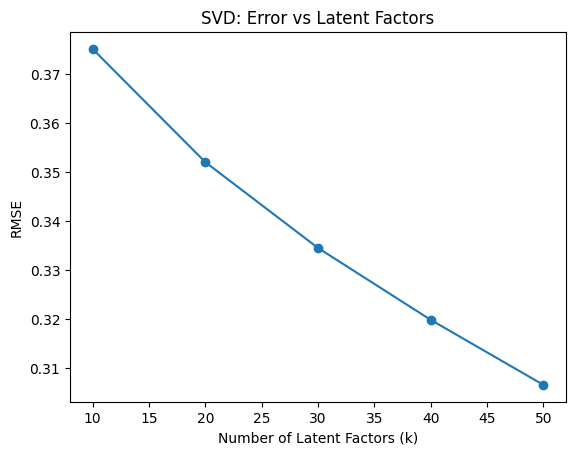

In [60]:
k_values = [10, 20, 30, 40, 50]
rmse_list = []

for k in k_values:
    svd = TruncatedSVD(n_components=k, random_state=42)
    U = svd.fit_transform(matrix_filled)
    VT = svd.components_
    pred = np.dot(U, VT)

    rmse = np.sqrt(mean_squared_error(matrix_filled.values, pred))
    rmse_list.append(rmse)

plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("SVD: Error vs Latent Factors")
plt.show()

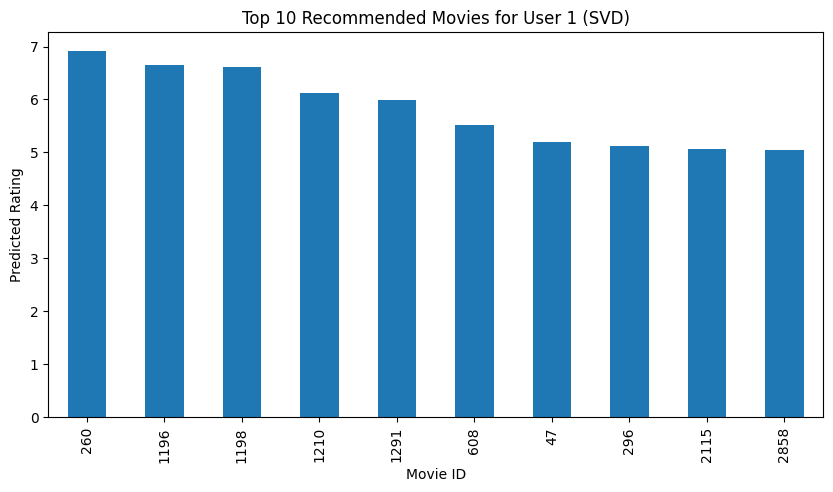

In [61]:
user_id = 1
top_movies = recommend_movies(user_id, 10)

plt.figure(figsize=(10,5))
top_movies.plot(kind='bar')
plt.title(f"Top 10 Recommended Movies for User {user_id} (SVD)")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()

NMF

In [62]:
nmf_model = NMF(
    n_components=50,
    init='nndsvd',   
    random_state=42,
    max_iter=500
)

W = nmf_model.fit_transform(matrix_filled)
H = nmf_model.components_

In [63]:
nmf_reconstructed = np.dot(W, H)

nmf_df = pd.DataFrame(nmf_reconstructed,
                      index=matrix_filled.index,
                      columns=matrix_filled.columns)

In [64]:
rmse_nmf = np.sqrt(mean_squared_error(actual, nmf_reconstructed))
mae_nmf = mean_absolute_error(actual, nmf_reconstructed)

print("NMF RMSE:", rmse_nmf)
print("NMF MAE:", mae_nmf)

NMF RMSE: 0.31831660786301164
NMF MAE: 0.06570034174069501


In [65]:
def nmf_recommend(user_id, n=5):
    user_ratings = nmf_df.loc[user_id]
    return user_ratings.sort_values(ascending=False).head(n)

print(nmf_recommend(1, 10))

movieId
1196    5.779533
260     5.576063
2571    5.408761
589     5.298639
1210    5.121370
1198    5.117906
1240    4.839296
2028    4.731074
480     4.513044
1200    4.505631
Name: 1, dtype: float64


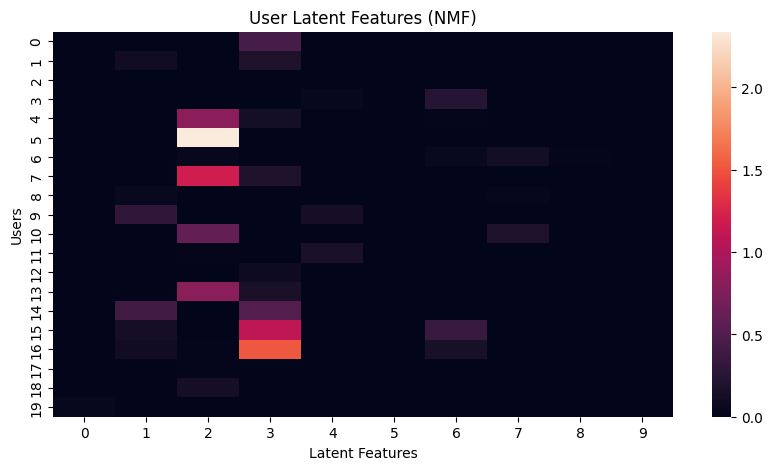

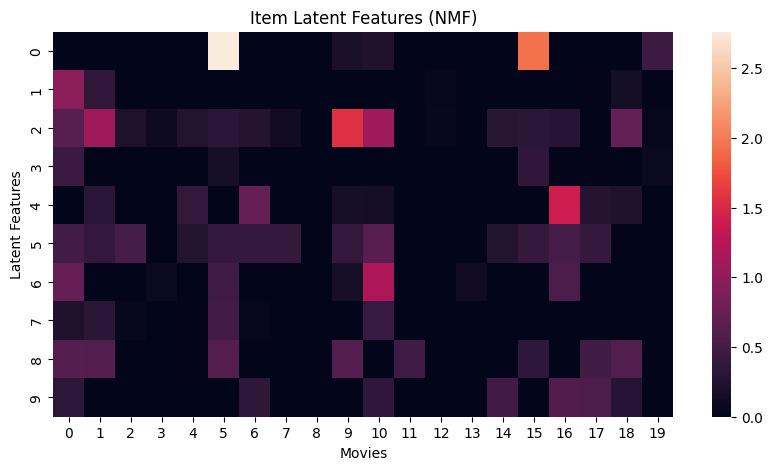

In [66]:
# User latent features (W matrix)
plt.figure(figsize=(10,5))
sns.heatmap(W[:20, :10])
plt.title("User Latent Features (NMF)")
plt.xlabel("Latent Features")
plt.ylabel("Users")
plt.show()

# Item latent features (H matrix)
plt.figure(figsize=(10,5))
sns.heatmap(H[:10, :20])
plt.title("Item Latent Features (NMF)")
plt.xlabel("Movies")
plt.ylabel("Latent Features")
plt.show()

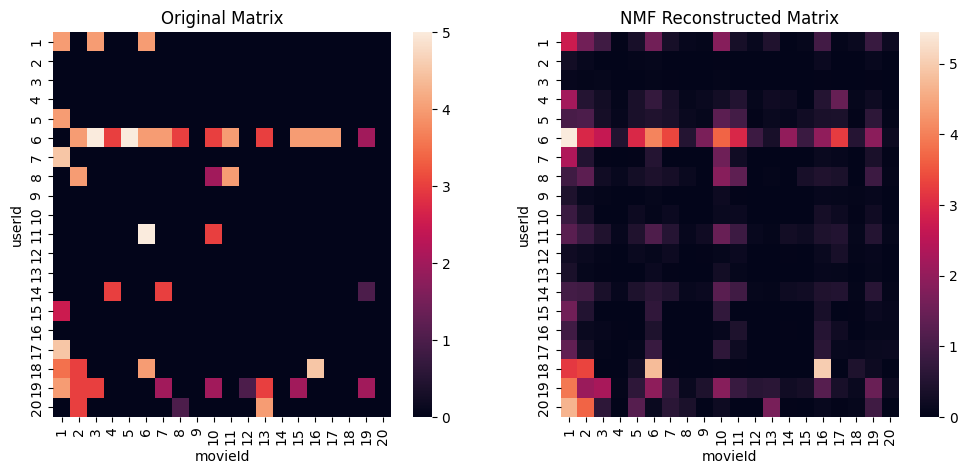

In [67]:
plt.figure(figsize=(12,5))

# Original matrix
plt.subplot(1,2,1)
sns.heatmap(matrix_filled.iloc[:20, :20])
plt.title("Original Matrix")

# NMF reconstructed matrix
plt.subplot(1,2,2)
sns.heatmap(nmf_df.iloc[:20, :20])
plt.title("NMF Reconstructed Matrix")

plt.show()

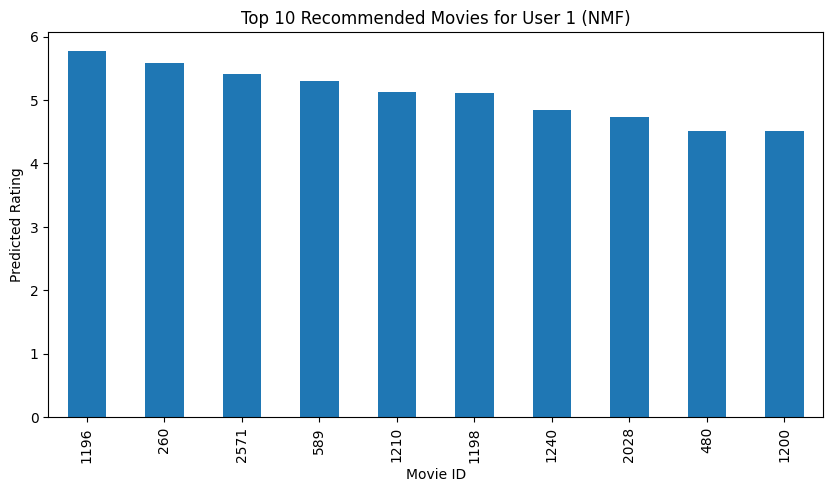

In [68]:
user_id = 1
top_movies_nmf = nmf_recommend(user_id, 10)

plt.figure(figsize=(10,5))
top_movies_nmf.plot(kind='bar')
plt.title(f"Top 10 Recommended Movies for User {user_id} (NMF)")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()

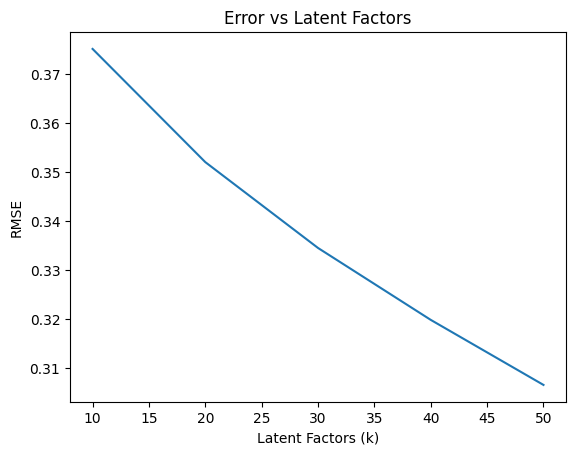

In [69]:
errors = []
k_values = [10, 20, 30, 40, 50]

for k in k_values:
    svd = TruncatedSVD(n_components=k, random_state=42)
    U = svd.fit_transform(matrix_filled)
    VT = svd.components_
    pred = np.dot(U, VT)
    
    rmse = np.sqrt(mean_squared_error(actual, pred))
    errors.append(rmse)

plt.plot(k_values, errors)
plt.xlabel("Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()